# Annual Sea Level Anomalies
```{glue:figure} SL_MMA_annual_station
:scale: 25%
:align: right
```

In this notebook, we'll be taking a look at sea level anomalies (SLA), which can be thought of as signals that differ from the climatology (of a station or region). For these products we'll focus on yearly anomalies. For a nice overview and animation of daily mean SLAs in the Hawaii and eastern Pacific region, see [Pacific Sea Level Monitoring](https://uhslc.soest.hawaii.edu/pacific-sea-level-monitoring/).


## Setup

As with previous sections, we first need to import the necessary libraries, establish our input/output directories, and set up some basic plotting rules. 


In [1]:
# import necessary libraries
import numpy as np
import xarray as xr
import datetime as dt
from pathlib import Path
import pandas as pd
import os
import os.path as op
import sys

# data retrieval libraries
import requests
from urllib.request import urlretrieve #used for downloading files
import json
import copernicusmarine

# data processing libraries
from scipy import stats
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from myst_nb import glue #used for figure numbering when exporting to LaTeX

sys.path.append("../../functions")
from data_downloaders import download_oni_index, download_uhslc_data
import importlib
import sea_level as sea_level_mod
importlib.reload(sea_level_mod)
from sea_level import (
    load_site_config,
    get_uhslc_datum,
    process_trend_with_nan,
    build_output_filename,
    build_site_tag,
    save_dict_json,
    save_table_to_csv,
)

from sea_level import detect_enso_events, process_trend_single_series
from sea_level_plotting import (
    plot_map,
    pacific_all_west_formatter,
    plot_tg_rsl_anomaly_annual,
    plot_anomaly_decadal_maps,
    plot_anomaly_station_series,
    plot_annual_range_fill,
)


In [2]:
data_dir = Path('../../../data')
path_figs = "../../../matrix_cc/figures"
data_dir = Path(data_dir,'sea_level')
output_dir = data_dir 

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)


## Load Site Data Sources

Next, we'll access data from the UHSLC. The selected tide gauge uses the UHSLC ID from the site configuration. We will import the netcdf file into our current data directory, and take a peek at the dataset. We will also import the datums for this location. 


In [3]:
site_config_path = Path('../../data/sites/palau.json')
site_cfg = load_site_config(site_config_path)
site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
uhslc_id = int(site_cfg.get('selected_uhslc_id'))
station = site_cfg.get('station', site_cfg.get('selected_station_name', 'Station'))
country = site_cfg.get('country', site_cfg.get('station_country_filter', 'Country'))
lat = float(site_cfg.get('station_lat', site_lat))
lon = float(site_cfg.get('station_lon', site_lon))

site_output_dir = Path('../../outputs') / build_site_tag(site_name, site_lon, site_lat)
site_output_dir.mkdir(parents=True, exist_ok=True)

# load pre-downloaded data
rsl = download_uhslc_data(data_dir, uhslc_id, frequency='daily')
rsl


<xarray.Dataset> Size: 249kB
Dimensions:               (record_id: 1, time: 20771)
Coordinates:
  * time                  (time) datetime64[ns] 166kB 1969-05-19T12:00:00 ......
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 83kB ...
    lat                   (record_id) float32 4B ...
    lon                   (record_id) float32 4B ...
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

Make relative to MSL (for anomaly analysis).


In [4]:
rsl


<xarray.Dataset> Size: 249kB
Dimensions:               (record_id: 1, time: 20771)
Coordinates:
  * time                  (time) datetime64[ns] 166kB 1969-05-19T12:00:00 ......
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 83kB ...
    lat                   (record_id) float32 4B ...
    lon                   (record_id) float32 4B ...
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

In [5]:
# extract the given datum from the dataframe
datumname = 'MSL'

datum, datumtable = get_uhslc_datum(uhslc_id, datumname)

rsl['datum'] = datum # already in mm
rsl['sea_level_msl'] = rsl['sea_level'] - rsl['datum']

# assign units to datum and sea level
rsl['datum'].attrs['units'] = 'mm'
rsl['sea_level_msl'].attrs['units'] = 'mm'


# calculate altimetry epoch mean for later use
epoch_daily_mean = rsl['sea_level_msl'].sel(time=slice('1993-01-01', '2012-12-31')).mean() 


#### 2. Now we'll remove the trend (over the entire record) from the station.


In [6]:
coefficients, trend_fxn, trend_rate = process_trend_single_series(rsl,'sea_level_msl')

sea_level_trend = trend_fxn(rsl['time'].astype('datetime64[D]').astype(float))
rsl['sea_level_anomaly_detrended'] = rsl['sea_level_msl'] - sea_level_trend


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_SeaLevel/notebooks/historical/../../functions/sea_level.py:410: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  time_num = data["time"].astype("datetime64[D]").astype(float)
/var/folders/88/z9xxhn052qddjc_ppp2j_8gr0000gn/T/ipykernel_51892/2072546405.py:3: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. T

#### 3. Resample to monthly time series of anomalies.


In [7]:
# resample to monthly time series 
rsl_monthly = rsl.resample(time='1MS',label='left').mean()

# get climatology (annual cycle) by grouping by month
rsl_climatology = rsl_monthly.groupby('time.month').mean('time')

# get anomalies by subtracting climatology from monthly data
rsl_anomalies = rsl_monthly.groupby('time.month') - rsl_climatology

rsl_anomalies


<xarray.Dataset> Size: 46kB
Dimensions:                      (record_id: 1, time: 683)
Coordinates:
  * record_id                    (record_id) int64 8B 7
  * time                         (time) datetime64[ns] 5kB 1969-05-01 ... 202...
    month                        (time) int64 5kB 5 6 7 8 9 10 ... 11 12 1 2 3
Data variables:
    sea_level                    (time, record_id) float32 3kB -74.49 ... 79.95
    lat                          (time, record_id) float32 3kB -4.768e-07 ......
    lon                          (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    station_country_code         (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    uhslc_id                     (time, record_id) float64 5kB 0.0 0.0 ... 0.0
    gloss_id                     (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    datum                        (time) float64 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sea_level_msl                (time, record_id) float64 5kB -74.49 ... 79.95
    sea_level_anomaly_detrended  (time, record_id) float64 5kB -11.97 ... 17.39

#### 4. Now sort the subset on "storm year" instead of calendar year for yearly means.


In [8]:
# change the index to be on storm_time instead of time
rsl_years = rsl.copy()
rsl_years['storm_time'] = rsl_years['time']
rsl_years['storm_time'] = xr.DataArray(
    pd.to_datetime(rsl_years['storm_time'].values).to_series().apply(
        lambda x: x if x.month >= 5 else x - pd.DateOffset(years=1)
    ),
    dims=rsl_years['storm_time'].dims,
    coords=rsl_years['storm_time'].coords
)
rsl_years = rsl_years.set_index(time='storm_time')

# # # rename the time dimension to storm_time
rsl_years = rsl_years.rename({'time':'storm_time'})
rsl_years


<xarray.Dataset> Size: 582kB
Dimensions:                      (record_id: 1, storm_time: 20771)
Coordinates:
  * storm_time                   (storm_time) datetime64[ns] 166kB 1969-05-19...
  * record_id                    (record_id) int64 8B 7
Data variables: (12/13)
    sea_level                    (record_id, storm_time) float32 83kB ...
    lat                          (record_id) float32 4B 7.33
    lon                          (record_id) float32 4B 134.5
    station_name                 (record_id) <U7 28B 'Malakal'
    station_country              (record_id) <U5 20B 'Palau'
    station_country_code         (record_id) float32 4B 585.0
    ...                           ...
    gloss_id                     (record_id) float32 4B 120.0
    ssc_id                       (record_id) |S4 4B b'mala'
    last_rq_date                 (record_id) datetime64[ns] 8B 2018-12-31T12:...
    datum                        float64 8B 1.532e+03
    sea_level_msl                (record_id, storm_time) float64 166kB -56.0 ...
    sea_level_anomaly_detrended  (record_id, storm_time) float64 166kB -11.68...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

In [9]:
# reorder to that storm_time is monotonicly increasing
rsl_subset = rsl_years.sortby('storm_time')

# Group by storm_year and record_id
rsl_yearly_mean = rsl_years.groupby('storm_time.year').mean('storm_time')

# give year dimension a name
rsl_yearly_mean = rsl_yearly_mean.rename({'year':'storm_year'})

rsl_yearly_mean


<xarray.Dataset> Size: 7kB
Dimensions:                      (storm_year: 57, record_id: 1)
Coordinates:
  * record_id                    (record_id) int64 8B 7
  * storm_year                   (storm_year) int64 456B 1969 1970 ... 2024 2025
Data variables: (12/13)
    sea_level                    (storm_year, record_id) float32 228B 1.454e+...
    lat                          (storm_year, record_id) float32 228B 7.33 .....
    lon                          (storm_year, record_id) float32 228B 134.5 ....
    station_name                 (storm_year, record_id) <U7 2kB 'Malakal' .....
    station_country              (storm_year, record_id) <U5 1kB 'Palau' ... ...
    station_country_code         (storm_year, record_id) float32 228B 585.0 ....
    ...                           ...
    gloss_id                     (storm_year, record_id) float32 228B 120.0 ....
    ssc_id                       (storm_year, record_id) |S4 228B b'mala' ......
    last_rq_date                 (storm_year, record_id) datetime64[ns] 456B ...
    datum                        (storm_year) float64 456B 1.532e+03 ... 1.53...
    sea_level_msl                (storm_year, record_id) float64 456B -77.87 ...
    sea_level_anomaly_detrended  (storm_year, record_id) float64 456B -34.68 ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

## Absolute Value: satellite (trend removed)


In [10]:
cmems_filename = site_cfg.get('cmems_filename')
cmems_path = Path(site_cfg.get('cmems_path', data_dir / (cmems_filename or '')))
if not cmems_path.exists():
    raise FileNotFoundError(
        f"CMEMS file not found: {cmems_path}. Run 0_site_setup.ipynb first to prepare site data."
    )

print(f'Using prepared CMEMS data: {cmems_path.name}')
cmems = xr.open_dataset(cmems_path, engine="h5netcdf", chunks="auto")

# slice the data to analysis period
start_date = site_cfg.get('start_date', '1993-01-01')
end_date = site_cfg.get('end_date', '2022-12-31')
cmems = cmems.sel(time=slice(start_date, end_date))
epoch_daily_mean_cmems = cmems['sla'].sel(time=slice(start_date, '2012-12-31')).mean()

# put cmems data into the same MSL (NTDE) reference frame
cmems['sla'] = cmems['sla'] - epoch_daily_mean_cmems - epoch_daily_mean


Using prepared CMEMS data: cmems_L4_SSH_0.125deg_1993_2025.nc


### Plot an area-wide map, with stations
First we'll need to make sure that our data is detrended properly in order to look at yearly anomalies.


In [12]:
# concentrating on decadal trends
# let's look at 1993-2003 and 2003-2013

trend_mag_cmems, trend_line_cmems, trend_rate_cmems, p_value_cmems, trend_err_cmems = process_trend_with_nan(cmems['sla'])


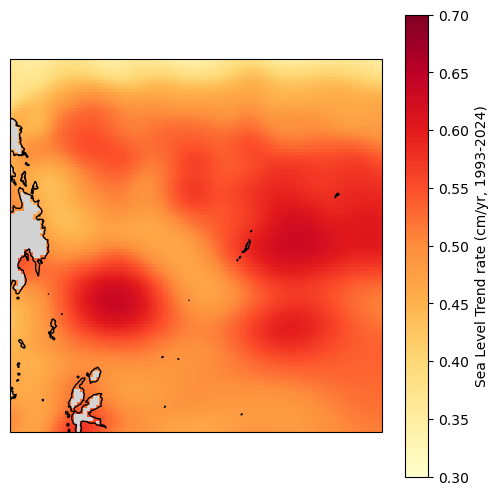

In [13]:
import warnings # import warnings to suppress warnings in cartopy
# Ignore the specific shapely warning for this cell
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in create_collection")


# define vmin and vmax variables
vmin = 0.3
vmax = 0.7
# Use float values for map extent to avoid dtype issues and ensure gridlines appear
xlims = [float(cmems.longitude.min()), float(cmems.longitude.max())]
ylims = [float(cmems.latitude.min()), float(cmems.latitude.max())]
trend_rate_cm = trend_rate_cmems * 100  # convert to cm/yr

# make ax,fig
crs = ccrs.PlateCarree()

fig, ax, crs, cmap = plot_map(vmin,vmax,xlims,ylims)
cmap = 'YlOrRd'
trend_rate_cm.plot(ax=ax, transform=crs,
                         vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=True, 
                         cbar_kwargs={'label': 'Sea Level Trend rate (cm/yr, 1993-2024)'}
)


# save the figure
# plt.savefig(output_dir / '1.2_cmems_trend_rate_1993_2024.png', dpi=300, bbox_inches='tight')


### Area-weighted average trend 

As an example, we can use the entire grid for this. That said, in reality, you'd want to pick boundaries that make more sense. You could, for example, use the EEZ.


In [14]:
startYear = '1993'
endYear = '2024'

# First, compute the area-weighted mean time series
weights = np.cos(np.deg2rad(cmems.latitude))
weights.name = "weights"
sla_weighted = cmems['sla'].sel(time=slice(startYear,endYear)).weighted(weights)
sla_regional_mean = sla_weighted.mean(dim=('latitude', 'longitude'))
trend_mag, trend_line, trend_rate, p_value, trend_err = process_trend_with_nan(sla_regional_mean)

trend_rate_computed = trend_rate.compute()
print(f'The trend rate for {startYear}-{endYear} in the entire grid is {trend_rate_computed*100:.2f} cm/yr')


The trend rate for 1993-2024 in the entire grid is 0.51 cm/yr


In [15]:
# concentrating on decadal trends
# let's look at 1993-2003 and 2003-2013
cmems1993_2003 = cmems.sel(time=slice('1993','2003'))

# get the overall trend (full time series)
trend_mag, sea_level_trend, trend_rate,p_value, trend_err = process_trend_with_nan(cmems['sla'])

sla_weighted = cmems['sla'].weighted(weights)
sla_regional_mean = sla_weighted.mean(dim=('latitude', 'longitude'))
trend_mag_area_weighted, sea_level_trend_area_weighted, trend_rate_area_weighted, p_value_area_weighted, trend_err_area_weighted = process_trend_with_nan(sla_regional_mean)


#remove the trend from the data
sla_detrended = cmems1993_2003['sla'] - sea_level_trend.sel(time=slice('1993','2003'))
sla_detrended_area_weighted = cmems1993_2003['sla'] - sea_level_trend_area_weighted


Let's check this for a random station in our list.


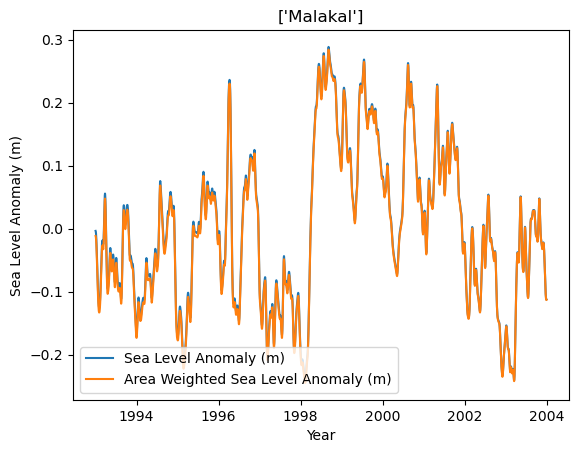

In [16]:
lat = rsl.lat
lon = rsl.lon
sla_detrended.sel(latitude=lat, longitude=lon, method='nearest').plot(label='Sea Level Anomaly (m)')
sla_detrended_area_weighted.sel(latitude=lat, longitude=lon, method='nearest').plot(label='Area Weighted Sea Level Anomaly (m)')

# change the title to station name
plt.title(rsl['station_name'].values)
#add axis labels
plt.xlabel('Year')
plt.ylabel('Sea Level Anomaly (m)')

plt.legend()


There are slight differences between removing the grid-level trend versus the area-weighted trend in this plot. Nothing too major here.


### Create a map
Concentrating on decadal trends.


In [17]:
# concentrating on decadal trends
# let's look at 1993-2003 and 2003-2013

yr_start = [1993,2003,2013,2003]
yr_stop = [2003,2013,2023,2023]

#do storm year instead of calendar year

yr_start_str = [str(int(yr))+'-05-01' for yr in yr_start]
yr_stop_str = [str(int(yr+1))+'-04-30' for yr in yr_stop]

trend_mag, sea_level_trend, trend_rate,p_value, trend_err = process_trend_with_nan(cmems['sla'].sel(time=slice(yr_start_str[0],yr_stop_str[-1])))

#remove the trend from the data
sla_detrended = cmems['sla'] - sea_level_trend 


In [18]:
rsl_anomalies


<xarray.Dataset> Size: 46kB
Dimensions:                      (record_id: 1, time: 683)
Coordinates:
  * record_id                    (record_id) int64 8B 7
  * time                         (time) datetime64[ns] 5kB 1969-05-01 ... 202...
    month                        (time) int64 5kB 5 6 7 8 9 10 ... 11 12 1 2 3
Data variables:
    sea_level                    (time, record_id) float32 3kB -74.49 ... 79.95
    lat                          (time, record_id) float32 3kB -4.768e-07 ......
    lon                          (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    station_country_code         (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    uhslc_id                     (time, record_id) float64 5kB 0.0 0.0 ... 0.0
    gloss_id                     (time, record_id) float32 3kB 0.0 0.0 ... 0.0
    datum                        (time) float64 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sea_level_msl                (time, record_id) float64 5kB -74.49 ... 79.95
    sea_level_anomaly_detrended  (time, record_id) float64 5kB -11.97 ... 17.39

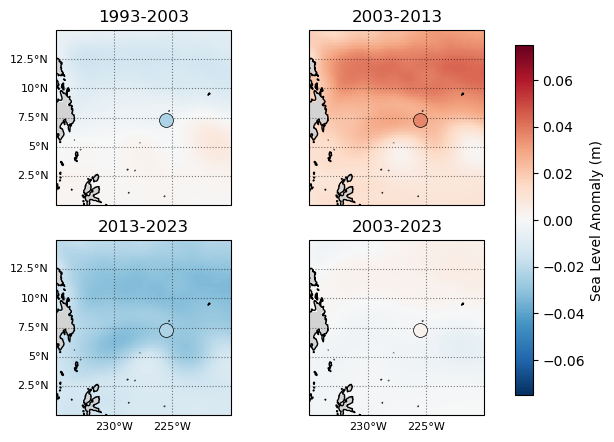

In [19]:
fig, _ = plot_anomaly_decadal_maps(
    sla_detrended=sla_detrended,
    rsl=rsl,
    rsl_anomalies=rsl_anomalies,
    yr_start=yr_start,
    yr_stop=yr_stop,
    yr_start_str=yr_start_str,
    yr_stop_str=yr_stop_str,
)

glue("SL_YMA_decadal", fig, display=False)

fig.savefig(
    site_output_dir / build_output_filename('1_2_2_SL_anomaly_annual_map_decadal', site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches='tight',
)


```{glue:figure} SL_YMA_decadal
:name: "SL_YMA_decadal"

Decadal (or bidecadal) mean anomalies of the Hawaiian Islands region, background trend (Storm Years 1993-2023) removed. Note that the sea level is plotted in units of m. The mean anomaly is near zero when using the full timeseries and grid-level trends (i.e. no area-weighted averaging). Mean monthly anomalies at the stations are plotted as well, showing similar-ish patterns.
```


## Time Series Plots
Now we'll look at monthly and yearly anomalies at the tide stations through time. We'll also plot ENSO signals on the same plot, to get a visual feel for any ENSO-driven anomalous effects on sea level.


First, we'll plot one gauge


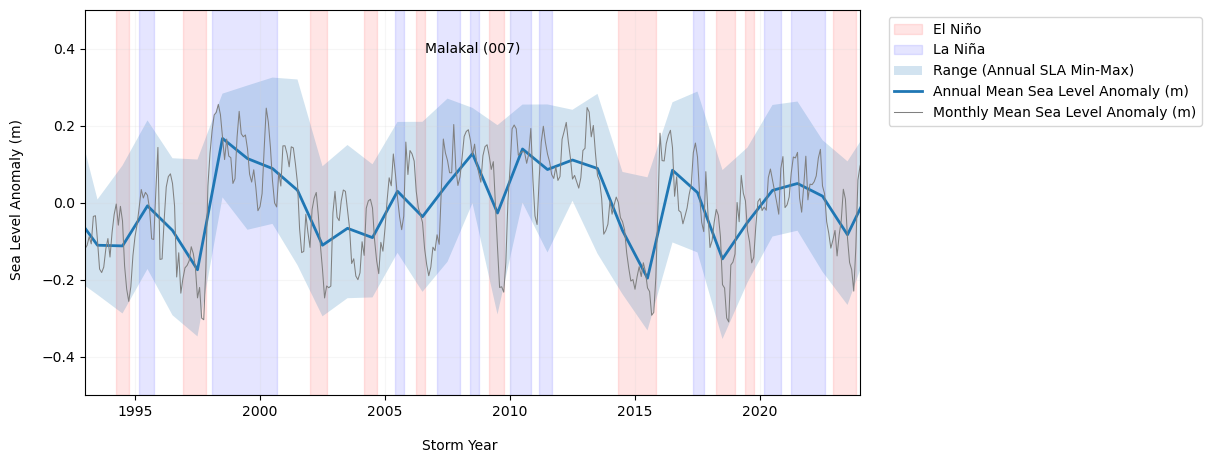

In [20]:
# add ENSO to the plots
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
oni = download_oni_index(p_data)

# adjust the index to be float value of fractional year (storm year)
enso_events = detect_enso_events(oni)
enso_events.index = pd.to_datetime(enso_events.index)
enso_events.index = enso_events.index.year + (enso_events.index.month - 1) / 12 - 5 / 12

fig, ax, station = plot_anomaly_station_series(
    rsl_yearly_mean=rsl_yearly_mean,
    rsl_years=rsl_years,
    rsl_monthly=rsl_monthly,
    enso_events=enso_events,
    sid=0,
)

glue('SL_MMA_annual_station', fig, display=False)
glue('station', station, display=False)


```{glue:figure} SL_MMA_annual_station
:name: "SL_MMA_annual_station"

Yearly mean anomalies at the {glue:text}`station` tide gauge with background trend removed (blue). The shaded region about the annual mean denotes the annual means of the daily min and max sea level. Note that the sea level is plotted in units of m. The monthly mean anomaly (gray) is calculated with respect to the annual cycle. El Niño and La Niño time periods are derived from the Oceanic Niño Index (ONI), available at https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php  
```


In [21]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
oni = download_oni_index(p_data)
enso_events = detect_enso_events(oni)
enso_events


,ONI,ONI Mode,year_storm,El Nino,La Nina
1951-01-01,-0.82,Neutral,1950,False,False
1951-02-01,-0.54,Neutral,1950,False,False
1951-03-01,-0.17,Neutral,1950,False,False
1951-04-01,0.18,Neutral,1950,False,False
1951-05-01,0.36,Neutral,1951,False,False
...,...,...,...,...,...
2026-08-01,NaN,Neutral,2026,False,False
2026-09-01,NaN,Neutral,2026,False,False
2026-10-01,NaN,Neutral,2026,False,False
2026-11-01,NaN,Neutral,2026,False,False


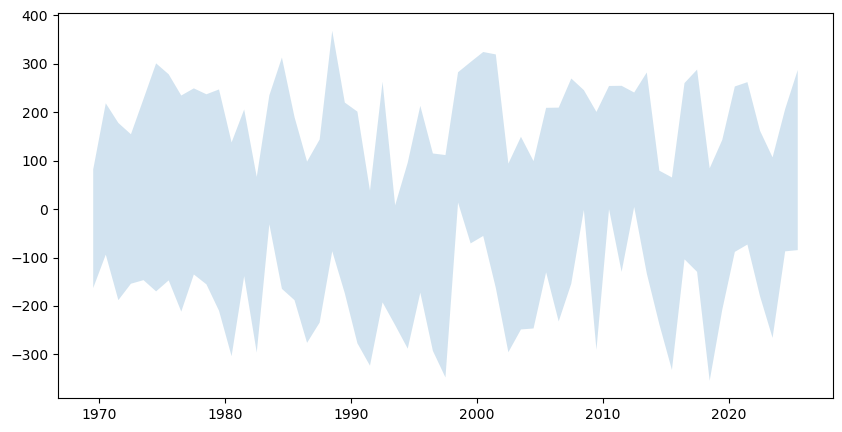

In [22]:
rsl_yearly_min = rsl_years.groupby('storm_time.year').min('storm_time').isel(record_id=0)
rsl_yearly_max = rsl_years.groupby('storm_time.year').max('storm_time').isel(record_id=0)
rsl_yearly_min = rsl_yearly_min['sea_level_anomaly_detrended']
rsl_yearly_max = rsl_yearly_max['sea_level_anomaly_detrended']
fig, ax = plot_annual_range_fill(rsl_yearly_mean, rsl_yearly_min, rsl_yearly_max)


In [23]:
# Save structured anomaly outputs for this site
anomaly_payload = {
    'site_name': site_name,
    'uhslc_id': int(uhslc_id),
}

if 'rsl_yearly_mean' in globals():
    yearly_cols = [col for col in ['storm_year', 'sea_level_anomaly_detrended'] if col in rsl_yearly_mean.to_dataframe().reset_index().columns]
    yearly_df = rsl_yearly_mean.to_dataframe().reset_index()[yearly_cols].copy()
    save_table_to_csv(
        yearly_df,
        site_output_dir,
        build_output_filename('SL_anomaly_yearly_mean', site_name, site_lon, site_lat, ext='csv'),
        index=False,
    )
    anomaly_payload['annual_mean_anomaly_stats'] = {
        'n_years': int(len(yearly_df)),
        'mean_cm': float(yearly_df['sea_level_anomaly_detrended'].mean()),
        'min_cm': float(yearly_df['sea_level_anomaly_detrended'].min()),
        'max_cm': float(yearly_df['sea_level_anomaly_detrended'].max()),
    }

if 'rsl_anomalies' in globals():
    anom_df = rsl_anomalies[['sea_level_anomaly_detrended']].to_dataframe().reset_index().dropna()
    save_table_to_csv(
        anom_df,
        site_output_dir,
        build_output_filename('SL_anomaly_monthly_series', site_name, site_lon, site_lat, ext='csv'),
        index=False,
    )
    anomaly_payload['monthly_anomaly_stats'] = {
        'n_points': int(len(anom_df)),
        'mean_cm': float(anom_df['sea_level_anomaly_detrended'].mean()),
        'std_cm': float(anom_df['sea_level_anomaly_detrended'].std()),
    }

save_dict_json(
    anomaly_payload,
    site_output_dir,
    build_output_filename('SL_anomaly_summary_metrics', site_name, site_lon, site_lat, ext='json'),
)


PosixPath('../../outputs/palau_lat7p340_lon134p620/SL_anomaly_summary_metrics_palau_lat7p340_lon134p620.json')